# MSTT Tutorial: Classification with OpenML Datasets


This tutorial demonstrates how to use MSTT for tabular classification with OpenML datasets.  
To simplify the workflow, we provide additional utilities for loading and preprocessing OpenML datasets.  
These utilities are intended for demonstration purposes and are not required to use MSTT with other data sources.

In [1]:
import sys
from pathlib import Path

# Main root of repo MSTT
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import os
import time
import numpy as np
import torch
from sklearn.metrics import classification_report
from sklearn.metrics import balanced_accuracy_score

import src.training as training
import src.testing as testing
import src.utils as utils
from src.model import MSTT
from src.preprocess_data import all_preprocess

import torch.optim
import torch.nn as nn
from torch.utils.data import  DataLoader
from tqdm.auto import tqdm # Loading bar

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')

## Configurations

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42
NUM_WORKERS = min(4, os.cpu_count())
print("device:", DEVICE)
print("num_workers:", NUM_WORKERS)

device: cuda
num_workers: 4


In [4]:
torch.manual_seed(SEED) # for CPU

# If GPU
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)  # si usas más de una GPU

# Deterministic options
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [5]:
MODEL_HYPERPARAMS = {
    "d_model": 128,
    "num_heads": 4,
    "hidden_dim_attmlp": 128 *2,  # d_model*2
    "hidden_dim_supmlp": 128,
    "num_learned_features": [[10, 10], [5, 5, 5]],
    "pos_norm": False,
    "bias_st_cat": True,
    "device" :  DEVICE, 
}

In [6]:
TRAINING_ARGS =  {
    "patience_early_stop":  10,
    "learning_rate" : 1e-4,
    "weight_decay" : 1e-4,
    "batch_size" : 64,
    "epochs" :  120
}

## Load and Preprocess an OpenML Dataset


Specify an OpenML dataset ID to load and preprocess a classification dataset using the provided `preprocessing.py` module.  
The preprocessing function performs the following operations:  
- Organizes the input features, placing numerical features first, followed by categorical features.
- Splits the dataset into training, validation, and test sets.
- Handles missing values when necessary.
- Standardizes numerical features.
- Encodes categorical features and target labels.

The module returns the preprocessed datasets and the relevant metadata required to configure and initialize the MSTT model.

In [7]:

X_train, X_val, X_test, y_train, y_val, y_test, num_idx, cat_idx, cat_cardinalities, n_classes = all_preprocess(id = 41143, # OpenML ID
                                                                                                                seed = SEED,
                                                                                                                test_size = 0.20,
                                                                                                                standardscaler_status=True) # Apply Standard Scaler 
print('X train shape: ', X_train.shape)
print('X val shape: ', X_val.shape)
print('X test shape: ', X_test.shape)
print('Index numerical features:', num_idx)
print('Index categorical features:', cat_idx)
print('Number of categories per feature:', cat_cardinalities)
print('Number of classes:', n_classes)

Dataset name:  jasmine
Columns with null values: []
Missing values:
Series([], dtype: float64)
Unique categories:  {'V1': 2, 'V2': 2, 'V3': 2, 'V4': 2, 'V5': 2, 'V6': 2, 'V7': 2, 'V8': 2, 'V9': 2, 'V10': 2, 'V11': 2, 'V12': 2, 'V14': 2, 'V15': 2, 'V16': 2, 'V17': 2, 'V18': 2, 'V19': 2, 'V20': 2, 'V21': 2, 'V22': 2, 'V24': 2, 'V25': 2, 'V26': 2, 'V27': 2, 'V28': 2, 'V29': 2, 'V30': 2, 'V31': 2, 'V32': 2, 'V33': 2, 'V34': 2, 'V35': 2, 'V36': 2, 'V37': 2, 'V38': 2, 'V39': 2, 'V40': 2, 'V41': 2, 'V42': 2, 'V44': 2, 'V46': 2, 'V47': 2, 'V48': 2, 'V49': 2, 'V50': 2, 'V51': 2, 'V52': 2, 'V53': 2, 'V54': 2, 'V55': 2, 'V57': 2, 'V58': 2, 'V60': 2, 'V61': 2, 'V62': 2, 'V63': 2, 'V64': 1, 'V65': 2, 'V66': 2, 'V67': 2, 'V68': 2, 'V69': 2, 'V70': 2, 'V71': 2, 'V72': 2, 'V73': 2, 'V74': 2, 'V75': 2, 'V76': 2, 'V77': 2, 'V78': 2, 'V79': 2, 'V80': 2, 'V81': 2, 'V82': 2, 'V83': 2, 'V84': 2, 'V85': 2, 'V86': 2, 'V87': 2, 'V88': 2, 'V89': 2, 'V90': 2, 'V91': 2, 'V92': 2, 'V93': 2, 'V94': 2, 'V95': 2, 'V9

## Data Preparation and configuration

To facilitate data handling during training and evaluation, we first
organize the preprocessed datasets into a dictionary containing the
training, validation, and test splits.

Each split contains the target labels (`y`) and, depending on the
dataset, numerical (`x_cont`) and/or categorical (`x_cat`) features.

This structure allows MSTT to handle datasets with numerical features,
categorical features, or a combination of both.

The resulting dictionaries are then converted into PyTorch-compatible
datasets using the `CustomDictDataset` class.

In [8]:
# Verify the number of numerical and/or categorical features
total_features = X_train.shape[1]
n_cont_features = len(num_idx)
n_categorical_features = len(cat_idx)
train_idx = X_train.shape[0]
print("Number of features: ", total_features)
print("Number of numerical features: ", n_cont_features)
print("Number of categorical features: ", n_categorical_features)

Number of features:  144
Number of numerical features:  8
Number of categorical features:  136


In [9]:
# Organize the preprocessed data into a dictionary containing
# the training, validation, and test splits.
#
# Each split initially contains the corresponding target labels.
# Numerical and categorical features are added only if present
# in the dataset.
data_numpy = {
    "train": {"y": y_train},
    "val": {"y": y_val},
    "test": {"y": y_test},
}
# Add numerical features, if available.
# Numerical features are stored under the "x_cont" key.
if n_cont_features != 0:
    data_numpy["train"]["x_cont"] = X_train[:, num_idx].astype(np.float32)
    data_numpy["val"]["x_cont"] = X_val[:, num_idx].astype(np.float32)
    data_numpy["test"]["x_cont"] = X_test[:, num_idx].astype(np.float32)
# Add categorical features, if available.
# Categorical features are stored under the "x_cat" key
if n_categorical_features != 0:
    data_numpy["train"]["x_cat"] = (X_train[:, cat_idx]).astype(np.int64)
    data_numpy["val"]["x_cat"] = (X_val[:, cat_idx]).astype(np.int64)
    data_numpy["test"]["x_cat"] = (X_test[:, cat_idx]).astype(np.int64)

In [10]:
# Get task type (binary classification or multiclass) 
if n_classes == 2:
    task_type = "binary"
    binary_class_state = True
else:
    task_type = "multiclass"
    binary_class_state = False
    
print("Task type: ", task_type)

# The output size.
d_out = n_classes if task_type == "multiclass" else 1

Task type:  binary


In [11]:
# >>> Convert data to tensors.
dataset = {
    part: {k: torch.as_tensor(v) for k, v in data_numpy[part].items()}
    for part in data_numpy
}

if task_type != "multiclass":
    # Required by F.binary_cross_entropy_with_logits
    for part in dataset:
        dataset[part]["y"] = dataset[part]["y"].float()

## Create PyTorch Datasets and DataLoaders

The organized data is converted into PyTorch tensors and wrapped
using `CustomDictDataset`.

Finally, DataLoaders are created to provide mini-batches during
model training, validation, and testing.

In [12]:
train_dataset = utils.CustomDictDataset(dataset['train'],
                                        binary_class_state)

test_dataset = utils.CustomDictDataset(dataset['test'],
                                       binary_class_state)

val_dataset = utils.CustomDictDataset(dataset['val'],
                                      binary_class_state)

In [13]:
train_dataloader = DataLoader(train_dataset, 
                              batch_size = TRAINING_ARGS['batch_size'], 
                              shuffle = True,
                              num_workers = NUM_WORKERS,
                              pin_memory=True)

test_dataloader = DataLoader(test_dataset, 
                             batch_size = TRAINING_ARGS['batch_size'], 
                             shuffle = False,
                             num_workers = NUM_WORKERS,
                             pin_memory=True)

val_dataloader = DataLoader(val_dataset, 
                            batch_size = TRAINING_ARGS['batch_size'], 
                            shuffle = False,
                            num_workers = NUM_WORKERS,
                            pin_memory=True)

## Model Preparation

In [14]:
MODEL_HYPERPARAMS.update({
    "cat_cardinalities": cat_cardinalities,
    "num_features" : total_features,
    "output_dim_supmlp" : d_out,
})

In [15]:
mstt_model = MSTT(**MODEL_HYPERPARAMS).to(DEVICE)

## Training Configuration

In [16]:
early_stopping = training.EarlyStopping(patience = TRAINING_ARGS['patience_early_stop'], 
                                     verbose = True)

In [17]:
# Define optimizer
optimizer = torch.optim.AdamW(mstt_model.parameters(), 
                              lr = TRAINING_ARGS['learning_rate'], 
                              weight_decay = TRAINING_ARGS['weight_decay'],
                              betas=(0.9, 0.98))
#Define loss function
if task_type == "multiclass":
    criterion = nn.CrossEntropyLoss()
else:
    criterion = nn.BCEWithLogitsLoss()
print(criterion)

BCEWithLogitsLoss()


## Model Training

In [ ]:
loss_train = []
acc_train = []
loss_val = []
acc_val = []
time_train = []

best_val_score = -float('inf')
patience = 7
epochs_without_improvement = 0
best_model_state = None  # To save best model

for epoch in tqdm(range(TRAINING_ARGS['epochs'])):
    print(f"Epoch: {epoch}\n--------" )
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        epoch_start = time.time()
    else:
        epoch_start = time.time()
    train_loss,train_acc,_ = training.train(mstt_model,
                                         train_dataloader,
                                         criterion,
                                         optimizer,
                                         DEVICE,
                                         binary_class_state)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        epoch_end= time.time()
    else:
        epoch_end= time.time()

    val_loss,val_acc,_ = training.validation(mstt_model,
                                          val_dataloader,
                                          criterion,
                                          DEVICE,
                                          binary_class_state)

    loss_train.append(train_loss)
    acc_train.append(train_acc)
    loss_val.append(val_loss)
    acc_val.append(val_acc)
    training_time = round(epoch_end - epoch_start, 4)

    print(f"Epoch {epoch+1} training time: {training_time} seconds")
    time_train.append(training_time)

     # Check early stopping
    early_stopping.step(val_loss, val_acc, mstt_model)


    if early_stopping.should_stop:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break



  0%|          | 0/120 [00:00<?, ?it/s]

Epoch: 0
--------
Epoch train time: 1.2667928s
Train loss: 0.6819 | Train acc: 65.6389%
Val loss: 0.6479 | Val acc: 79.2887% | Time: 0.1811s
Epoch 1 training time: 1.2713 seconds
Epoch: 1
--------
Epoch train time: 1.0030517s
Train loss: 0.6064 | Train acc: 78.2534%
Val loss: 0.5475 | Val acc: 77.6151% | Time: 0.1706s
Epoch 2 training time: 1.0067 seconds
Epoch: 2
--------
Epoch train time: 0.9905036s
Train loss: 0.5342 | Train acc: 77.2586%
Val loss: 0.5329 | Val acc: 75.3138% | Time: 0.1755s
Epoch 3 training time: 0.9934 seconds
Epoch: 3
--------
Epoch train time: 0.9820920s
Train loss: 0.4855 | Train acc: 78.3074%
Val loss: 0.4366 | Val acc: 79.9163% | Time: 0.1769s
Epoch 4 training time: 0.9852 seconds
Epoch: 4
--------
Epoch train time: 0.9725772s
Train loss: 0.4367 | Train acc: 79.8773%
Val loss: 0.4578 | Val acc: 78.4519% | Time: 0.1787s
Epoch 5 training time: 0.9757 seconds
No improvement in 1/10 epochs
Epoch: 5
--------
Epoch train time: 0.9984862s
Train loss: 0.4467 | Train a

In [ ]:
train_time = sum(time_train)/len(time_train)
print('Av training time: ', train_time)

Av training time:  0.9660500000000002


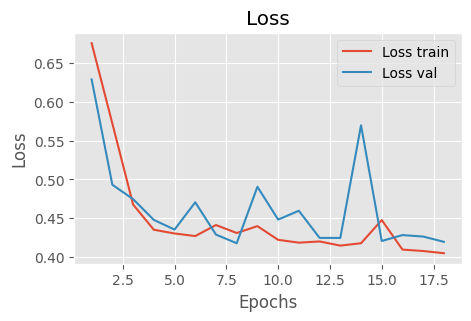

In [ ]:
plt.figure(figsize=(5,3))
plt.plot(np.arange(1,len(loss_val)+1), loss_train)
plt.plot(np.arange(1,len(loss_val)+1), loss_val)
plt.title('Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(['Loss train', 'Loss val'])
plt.show()

In [ ]:
mstt_model.load_state_dict(early_stopping.best_model_state)

<All keys matched successfully>

In [ ]:
y_true,y_preds = testing.evaluate_model(mstt_model,
                                        test_dataloader,
                                        DEVICE,
                                        binary_class_state)

NameError: name 'testing' is not defined

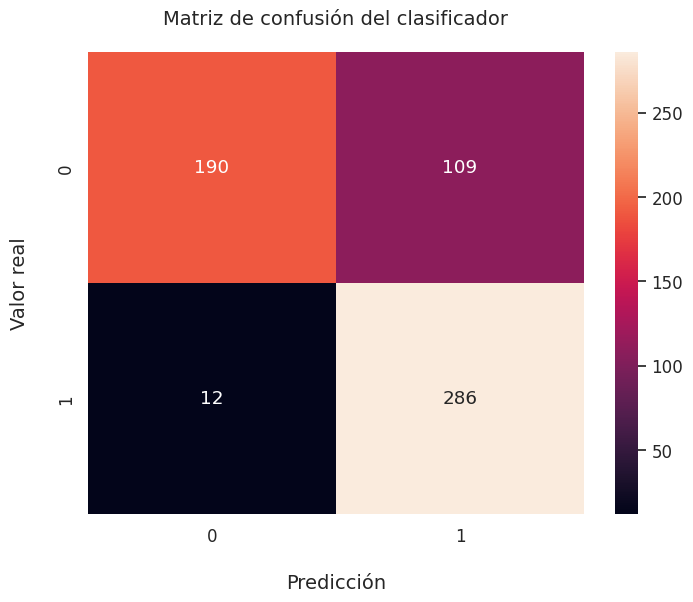

In [ ]:
y_true = y_true.numpy()
y_preds = y_preds.numpy()
testing.plot_confussion_matrix(y_true,y_preds)

In [ ]:
print(classification_report(y_true, y_preds))

              precision    recall  f1-score   support

         0.0       0.94      0.64      0.76       299
         1.0       0.72      0.96      0.83       298

    accuracy                           0.80       597
   macro avg       0.83      0.80      0.79       597
weighted avg       0.83      0.80      0.79       597



In [ ]:
y_true,y_preds = testing.evaluate_model(mstt_model,train_dataloader,DEVICE,binary_class_state)
train_acc = balanced_accuracy_score(y_true, y_preds)

y_true,y_preds = testing.evaluate_model(mstt_model,val_dataloader,DEVICE,binary_class_state)
val_acc = balanced_accuracy_score(y_true, y_preds)

y_true,y_preds = testing.evaluate_model(mstt_model,test_dataloader,DEVICE,binary_class_state)
test_acc = balanced_accuracy_score(y_true, y_preds)

print('train_acc: ', train_acc, 'val_acc: ', val_acc,'test_acc: ', test_acc)

NameError: name 'testing' is not defined